In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv('train.csv')

In [3]:
df.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,1,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,1,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,1,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,1,STANDING


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 563 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), int64(1), object(1)
memory usage: 31.6+ MB


In [5]:
df.isnull().sum()

,0
tBodyAcc-mean()-X,0
tBodyAcc-mean()-Y,0
tBodyAcc-mean()-Z,0
tBodyAcc-std()-X,0
tBodyAcc-std()-Y,0
...,...
"angle(X,gravityMean)",0
"angle(Y,gravityMean)",0
"angle(Z,gravityMean)",0
subject,0


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
# Check for infinite values (common in division-by-zero during standard deviation calculations)
numeric_cols = df.select_dtypes(include=[np.number]).columns
print(
    "Total Infinite Values:", np.isinf(df[numeric_cols]).values.sum()
)  # noqa: F821

# Check data types (All features should be float, target should be object/string)
print(df.dtypes.value_counts())

Total Infinite Values: 0
float64    561
int64        1
object       1
Name: count, dtype: int64


#`eda`

In [8]:
# Check dimensions
print("Shape of data:", df.shape)

# Check target distribution
print(df["Activity"].value_counts())

Shape of data: (7352, 563)
Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64


so our target column is balanced

Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64


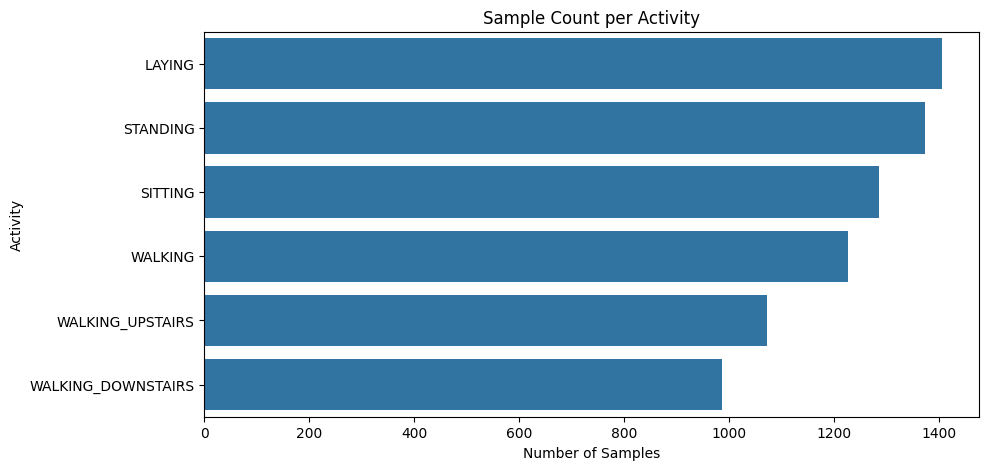

In [9]:
# Check how many samples exist for each activity label
activity_counts = df["Activity"].value_counts()
print(activity_counts)

# Visualize class distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.countplot(y="Activity", data=df, order=activity_counts.index)
plt.title("Sample Count per Activity")
plt.xlabel("Number of Samples")
plt.ylabel("Activity")
plt.show()

Visualize Feature Separability

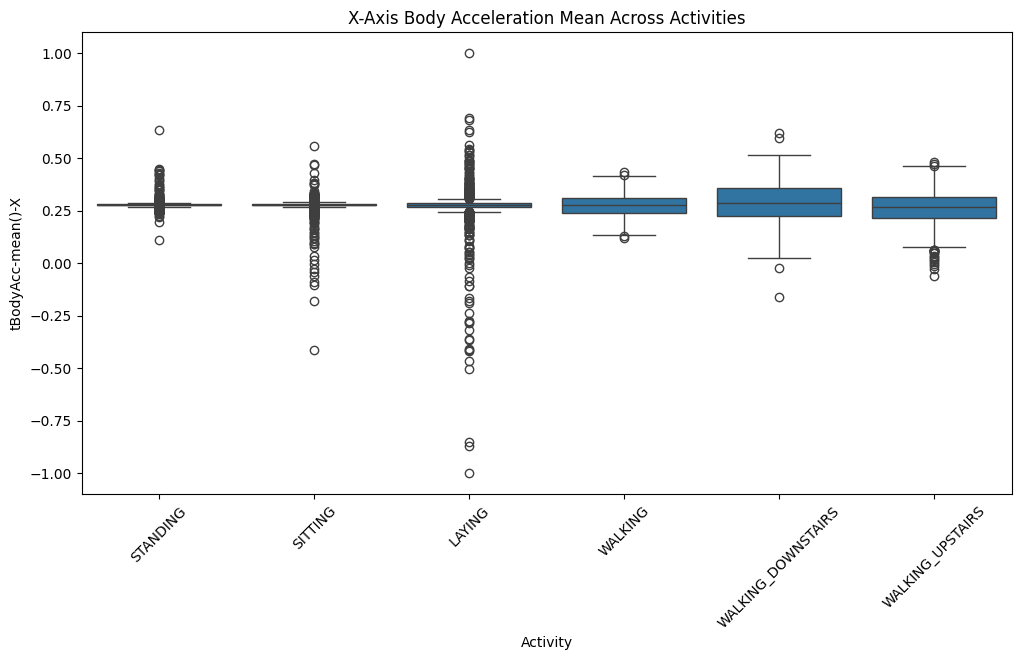

In [10]:

# Example: Check how a primary acceleration feature changes across activities
plt.figure(figsize=(12, 6))
sns.boxplot(x="Activity", y="tBodyAcc-mean()-X", data=df)
plt.xticks(rotation=45)
plt.title("X-Axis Body Acceleration Mean Across Activities")
plt.show()

This graph shows how the average X-axis movement value (tBodyAcc-mean()-X) changes across six different human activities (Standing, Sitting, Laying, Walking, Walking Downstairs, Walking Upstairs)

 - The Horizontal Line (The Box): For static postures like Standing, Sitting, and Laying, the box is extremely flat and compressed right around $0.28$. This means when you are still, your body's acceleration along the X-axis stays very consistent and changes very little

- The Spread & Shift: For dynamic activities like Walking and Walking Upstairs/Downstairs, the boxes are taller and slightly shifted. This tells us that movement causes the mean acceleration value to fluctuate more widely.

- The Circles (Dots): These are individual data points falling outside the main distribution range. In sensor data, these aren't "mistakes"—they represent unique physical variations (like someone shifting their weight or moving slightly while standing or laying down)

Check Feature Correlation (Multicollinearity Check)

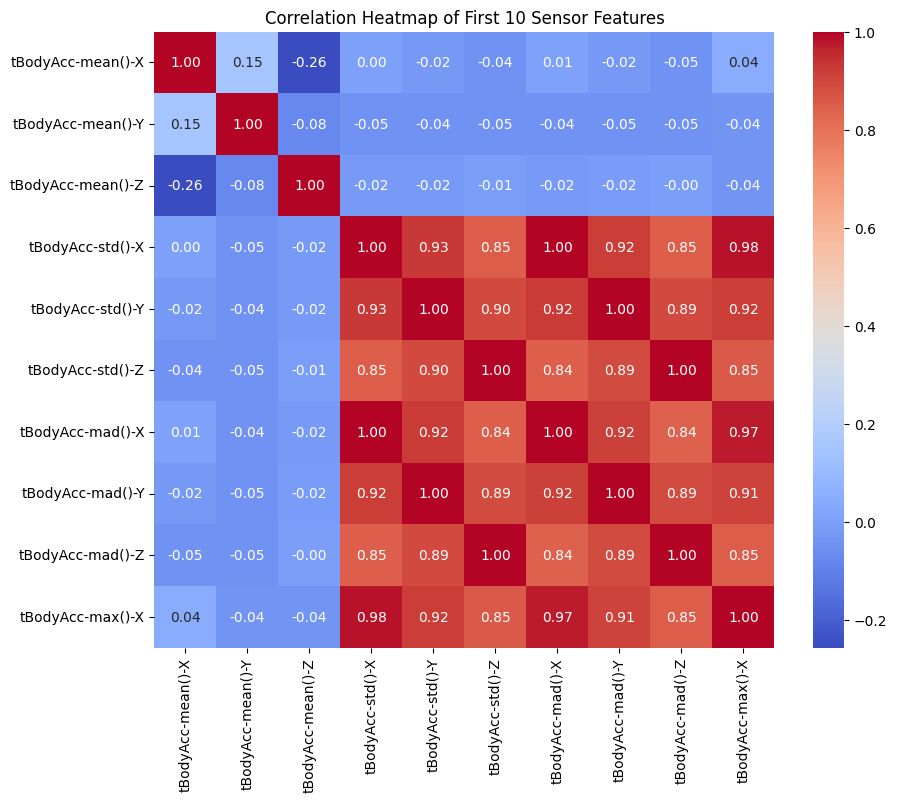

In [11]:
# Calculate correlation matrix for the first 10 numerical features
corr_matrix = df.iloc[:, :10].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of First 10 Sensor Features")
plt.show()

This heatmap measures how closely related different features are to each other, on a scale from -1 to +1:

1.00 (Dark Red): Perfect positive correlation. If one feature goes up, the other goes up by the exact same proportion.

Near 0.00 (Blue/Neutral): No relationship.

Negative values (Blue): Inverse relationship.

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ==========================================
# STEP 1: LOAD & QUICK SANITY CHECK
# ==========================================

# ==========================================
# STEP 2: PREPARE FEATURES (X) AND TARGET (y)
# ==========================================
# We drop the 'Activity' column for features, and isolate it as our target
X = df.drop(columns=["Activity"])
y = df["Activity"]

# ==========================================
# STEP 3: TRAIN-TEST SPLIT (CRITICAL: Before Scaling)
# ==========================================
# stratify=y ensures both train and test sets have the same proportion of each activity
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==========================================
# STEP 4: STANDARDIZATION (Scaling features)
# ==========================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(
    X_test
)  # Transform test using train's stats to avoid data leakage

# ==========================================
# STEP 5: TRAIN MULTI-CLASS LOGISTIC REGRESSION
# ==========================================
# 'multinomial' handles classification across all 6 activities natively
log_reg = LogisticRegression(
    multi_class="multinomial", solver="lbfgs", max_iter=1000, random_state=42
)

print("\nTraining the Multi-Class Logistic Regression model...")
log_reg.fit(X_train_scaled, y_train)
print("Training complete!")

# ==========================================
# STEP 6: EVALUATE MODEL PERFORMANCE
# ==========================================
y_pred = log_reg.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy * 100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))


Training the Multi-Class Logistic Regression model...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Training complete!

Model Accuracy: 98.50%

Classification Report:
                    precision    recall  f1-score   support

            LAYING       1.00      1.00      1.00       282
           SITTING       0.96      0.96      0.96       257
          STANDING       0.96      0.96      0.96       275
           WALKING       1.00      1.00      1.00       245
WALKING_DOWNSTAIRS       1.00      1.00      1.00       197
  WALKING_UPSTAIRS       1.00      1.00      1.00       215

          accuracy                           0.99      1471
         macro avg       0.99      0.99      0.99      1471
      weighted avg       0.99      0.99      0.99      1471



In [13]:
# Calculate training accuracy
train_preds = log_reg.predict(X_train_scaled)
train_accuracy = accuracy_score(y_train, train_preds)

# Calculate testing accuracy
test_preds = log_reg.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, test_preds)

print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Testing Accuracy:  {test_accuracy * 100:.2f}%")

# Check the gap
gap = (train_accuracy - test_accuracy) * 100
print(f"Gap between Train and Test: {gap:.2f}%")

Training Accuracy: 99.71%
Testing Accuracy:  98.50%
Gap between Train and Test: 1.21%


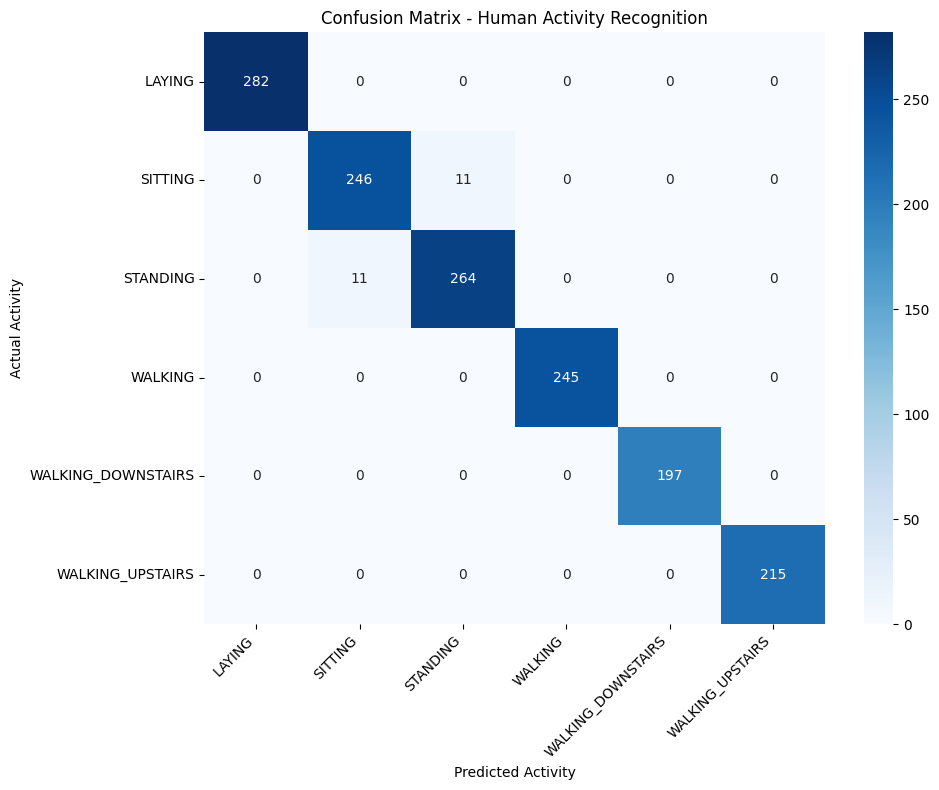

In [14]:
from sklearn.metrics import confusion_matrix

# 1. Generate the confusion matrix using y_test (true labels) and y_pred (predicted labels)
cm = confusion_matrix(y_test, y_pred)

# 2. Extract the class labels order from the model
class_labels = log_reg.classes_

# 3. Plot the confusion matrix using Seaborn heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels,
)

plt.title("Confusion Matrix - Human Activity Recognition")
plt.xlabel("Predicted Activity")
plt.ylabel("Actual Activity")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# testing test dataset

In [17]:
# Load your separate test dataset (replace with your actual filename)
df_test = pd.read_csv('test.csv')

print(f"Test Dataset Shape: {df_test.shape}")
print(f"Missing Values: {df_test.isnull().sum().sum()}")
print(
    "Infinite Values:",
    np.isinf(df_test.select_dtypes(include=[np.number])).values.sum(),
)

# Optional: Check for duplicate rows
print(f"Duplicate Rows: {df_test.duplicated().sum()}")

Test Dataset Shape: (2947, 563)
Missing Values: 0
Infinite Values: 0
Duplicate Rows: 0


In [18]:
X_test_official = df_test.drop(columns=['Activity'])
y_test_official = df_test['Activity']

In [19]:
# Scale using the existing scaler fitted from your training data
X_test_official_scaled = scaler.transform(X_test_official)

# Predict on the official test set
final_preds = log_reg.predict(X_test_official_scaled)

# Calculate final real-world accuracy
final_accuracy = accuracy_score(y_test_official, final_preds)
print(f"Official Test Dataset Accuracy: {final_accuracy * 100:.2f}%")

Official Test Dataset Accuracy: 95.08%


In [20]:
# Calculate training accuracy (using your training features)
train_preds = log_reg.predict(X_train_scaled)
train_accuracy = accuracy_score(y_train, train_preds)

# Calculate official test accuracy (using your preprocessed test features)
test_accuracy = accuracy_score(y_test_official, final_preds)

print(f"Training Accuracy: {train_accuracy * 100:.2f}%")
print(f"Official Test Accuracy: {test_accuracy * 100:.2f}%")

# Check the gap
gap = (train_accuracy - test_accuracy) * 100
print(f"Train-Test Gap: {gap:.2f}%")

Training Accuracy: 99.71%
Official Test Accuracy: 95.08%
Train-Test Gap: 4.63%


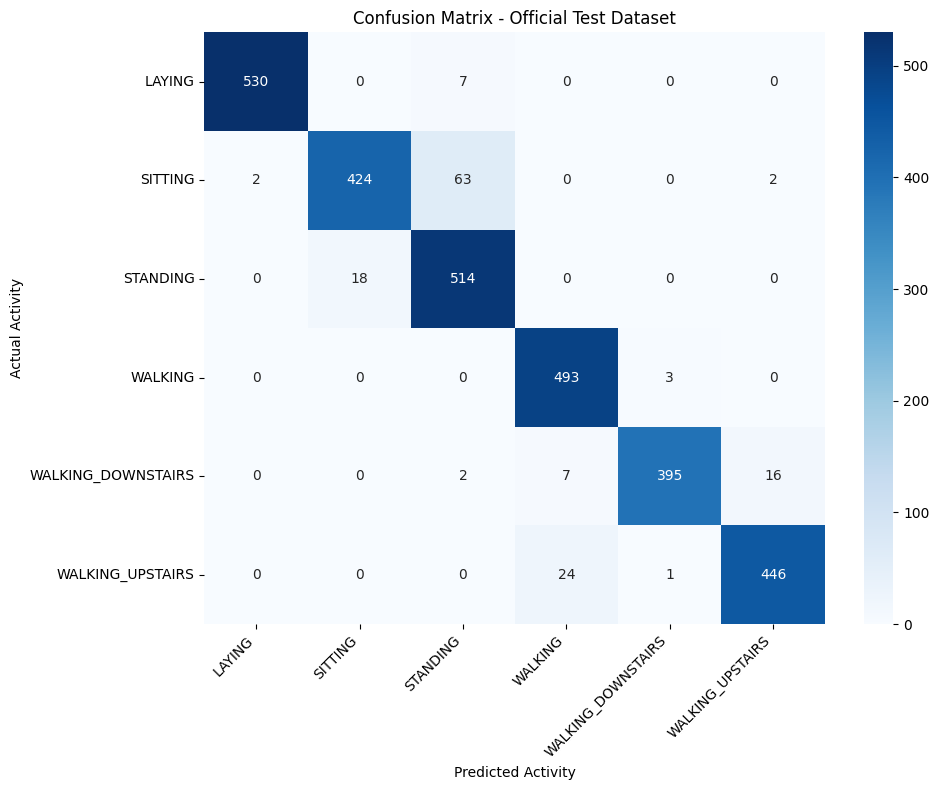

In [21]:

# Generate confusion matrix using the official test labels and predictions
cm_official = confusion_matrix(y_test_official, final_preds)
class_labels = log_reg.classes_

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_official,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels,
)

plt.title("Confusion Matrix - Official Test Dataset")
plt.xlabel("Predicted Activity")
plt.ylabel("Actual Activity")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()